# Axial Seamount Ray Coverage Analysis

Loads the MLDD 2015–2021 catalog, traces straight rays through the 3D S-wave velocity model of Baillard & Wilcock (2019) from each earthquake location to each station, and visualizes coverage geometry and incidence angles in 2D and 3D. Travel times are computed by integrating slowness along each straight-ray path through the heterogeneous velocity grid.

In [1]:
import numpy as np
np.infty = np.inf   # pykonal 0.4.1 compatibility with NumPy 2.0

import pykonal
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import LineCollection

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

## 1. Load Data

In [2]:
# Station locations from stations_axial.llz
stations = pd.read_csv(
    '../data/stations_axial.llz',
    sep=r'\s+',
    names=['lon', 'lat', 'elev_km', 'station'],
    engine='python'
).set_index('station')

print('Stations:')
print(stations.to_string())

Stations:
                lon       lat  elev_km
station                               
AXAS1   -129.999289  45.93356  -1.5290
AXAS2   -130.014100  45.93377  -1.5444
AXBA1   -129.736700  45.82018  -2.6072
AXCC1   -130.008900  45.95468  -1.5280
AXEC1   -129.979700  45.94958  -1.5120
AXEC2   -129.973800  45.93967  -1.5190
AXEC3   -129.978500  45.93607  -1.5160
AXID1   -129.978000  45.92573  -1.5275


In [3]:
# MLDD catalog: one row per earthquake–station pair
catalog = pd.read_csv('../data/mldd_catalog_2015_2021.csv', parse_dates=['event_datetime'])

print(f'Total rows: {len(catalog):,}')
print(f'Columns: {list(catalog.columns)}')
print(f'Stations in catalog: {sorted(catalog["station"].unique())}')
print(catalog.groupby('station').size().rename('n_pairs'))

Total rows: 585,274
Columns: ['station', 'arrival_time_p', 'event_datetime', 'arrival_time_s', 'event_lat', 'event_lon', 'event_depth', 'event_magnitude']
Stations in catalog: ['AXAS1', 'AXAS2', 'AXCC1', 'AXEC1', 'AXEC2', 'AXEC3']
station
AXAS1     77793
AXAS2     51614
AXCC1     74252
AXEC1    125620
AXEC2    124144
AXEC3    131851
Name: n_pairs, dtype: int64


## 2. Coordinate Conversion — Flat-Earth Local x/y/z

Reference point at the caldera center. Earthquake `event_depth` is km below the seafloor (positive down). Station elevations are km below sea level (negative values), so stations sit at the seafloor (~z = 0 in the subsurface reference frame).

In [4]:
REF_LON = -130.00
REF_LAT =  45.94

KM_PER_DEG_LAT = 111.32
KM_PER_DEG_LON = 111.32 * np.cos(np.radians(REF_LAT))

def ll_to_xy(lat, lon):
    x = (np.asarray(lon) - REF_LON) * KM_PER_DEG_LON  # east, km
    y = (np.asarray(lat) - REF_LAT) * KM_PER_DEG_LAT  # north, km
    return x, y

# Earthquake local coordinates
catalog['eq_x'], catalog['eq_y'] = ll_to_xy(catalog['event_lat'], catalog['event_lon'])
catalog['eq_z'] = catalog['event_depth']  # km below seafloor, positive down

# Station local coordinates
stations['x'], stations['y'] = ll_to_xy(stations['lat'], stations['lon'])
# Stations are at the seafloor; elev_km ~ -1.5 km, so z ≈ 0 below seafloor
MEAN_SEAFLOOR_KM = stations['elev_km'].abs().mean()
stations['z'] = np.maximum(MEAN_SEAFLOOR_KM + stations['elev_km'], 0.0)

print(f'Mean seafloor depth: {MEAN_SEAFLOOR_KM:.3f} km below sea level')
print('Station local coords (km from ref):')
print(stations[['x', 'y', 'z']].to_string())



Mean seafloor depth: 1.660 km below sea level
Station local coords (km from ref):
                 x          y         z
station                                
AXAS1     0.055041  -0.716901  0.131388
AXAS2    -1.091526  -0.693524  0.115988
AXBA1    20.382891 -13.338362  0.000000
AXCC1    -0.688977   1.634178  0.132388
AXEC1     1.571488   1.066446  0.148388
AXEC2     2.028225  -0.036736  0.141388
AXEC3     1.664383  -0.437488  0.144388
AXID1     1.703090  -1.588536  0.132888


## 3. 3D S-wave Velocity Model — Baillard & Wilcock (2019)

Loads the NonLinLoc 3D Vs grid. The model spans a 302×302×92 node grid at 50 m spacing (15×15×4.6 km), referenced to lat=45.9°N, lon=−130.1°E. Depth ranges from ~2 km above the seafloor to ~2.5 km below.

In [5]:
from scipy.ndimage import map_coordinates

# NLL grid parameters (from AXIAL_MODEL_3P_VELOCITY.S.mod.hdr)
NLL_NX, NLL_NY, NLL_NZ = 302, 302, 92
NLL_OX, NLL_OY, NLL_OZ = 0.0, 0.0, -0.5   # km (NLL grid origin)
NLL_DX, NLL_DY, NLL_DZ = 0.05, 0.05, 0.05  # km grid spacing
NLL_LAT_ORIG, NLL_LON_ORIG = 45.9, -130.1   # geographic reference

# Offsets: x_nll = x_nb + NB_TO_NLL_XOFF  (add to convert notebook → NLL coords)
KM_PER_DEG_LON_NLL = 111.32 * np.cos(np.radians(NLL_LAT_ORIG))
NB_TO_NLL_XOFF = (REF_LON - NLL_LON_ORIG) * KM_PER_DEG_LON_NLL
NB_TO_NLL_YOFF = (REF_LAT - NLL_LAT_ORIG) * 111.32

# Grid axes in notebook/plot coordinates (km from ref)
nll_x_nb = np.arange(NLL_NX) * NLL_DX - NB_TO_NLL_XOFF
nll_y_nb = np.arange(NLL_NY) * NLL_DY - NB_TO_NLL_YOFF
nll_z_sf = np.arange(NLL_NZ) * NLL_DZ + NLL_OZ - MEAN_SEAFLOOR_KM  # depth below seafloor

# Read NLL float32 binary buffer (ix varies slowest, iz varies fastest)
with open('../data/AXIAL_MODEL_3P_VELOCITY.S.mod.buf', 'rb') as f:
    vel_3d = np.frombuffer(f.read(), dtype=np.float32).reshape(NLL_NX, NLL_NY, NLL_NZ).copy()

print(f'Notebook→NLL offset: x + {NB_TO_NLL_XOFF:.3f} km, y + {NB_TO_NLL_YOFF:.3f} km')
print(f'Grid in notebook coords: '
      f'x [{nll_x_nb[0]:.1f}, {nll_x_nb[-1]:.1f}] km, '
      f'y [{nll_y_nb[0]:.1f}, {nll_y_nb[-1]:.1f}] km, '
      f'z [{nll_z_sf[0]:.2f}, {nll_z_sf[-1]:.2f}] km below seafloor')
print(f'Vs range: {vel_3d.min():.2f}–{vel_3d.max():.2f} km/s')

# Colormap for velocity model plots (used in cells 9 and 10)
vel_norm = mcolors.Normalize(vmin=2.5, vmax=4.5)
vel_cmap = cm.RdBu_r

# Station color map (used in velocity model plots; redefined from catalog in section 5)
sta_cmap  = plt.cm.tab10
sta_list  = sorted(stations.index.tolist())
sta_color = {s: sta_cmap(i / max(len(sta_list) - 1, 1)) for i, s in enumerate(sta_list)}

def vel_sample(x_nb, y_nb, z_sf):
    """Trilinearly interpolate Vs (km/s) at notebook coordinates (any array shape)."""
    x_nll = np.asarray(x_nb, dtype=float) + NB_TO_NLL_XOFF
    y_nll = np.asarray(y_nb, dtype=float) + NB_TO_NLL_YOFF
    z_nll = np.asarray(z_sf, dtype=float) + MEAN_SEAFLOOR_KM
    ix = (x_nll - NLL_OX) / NLL_DX
    iy = (y_nll - NLL_OY) / NLL_DY
    iz = (z_nll - NLL_OZ) / NLL_DZ
    coords = np.array([ix.ravel(), iy.ravel(), iz.ravel()])
    v = map_coordinates(vel_3d, coords, order=1, mode='nearest')
    return v.reshape(np.shape(x_nb))

Notebook→NLL offset: x + 7.747 km, y + 4.453 km
Grid in notebook coords: x [-7.7, 7.3] km, y [-4.5, 10.6] km, z [-2.16, 2.39] km below seafloor
Vs range: 0.49–3.62 km/s


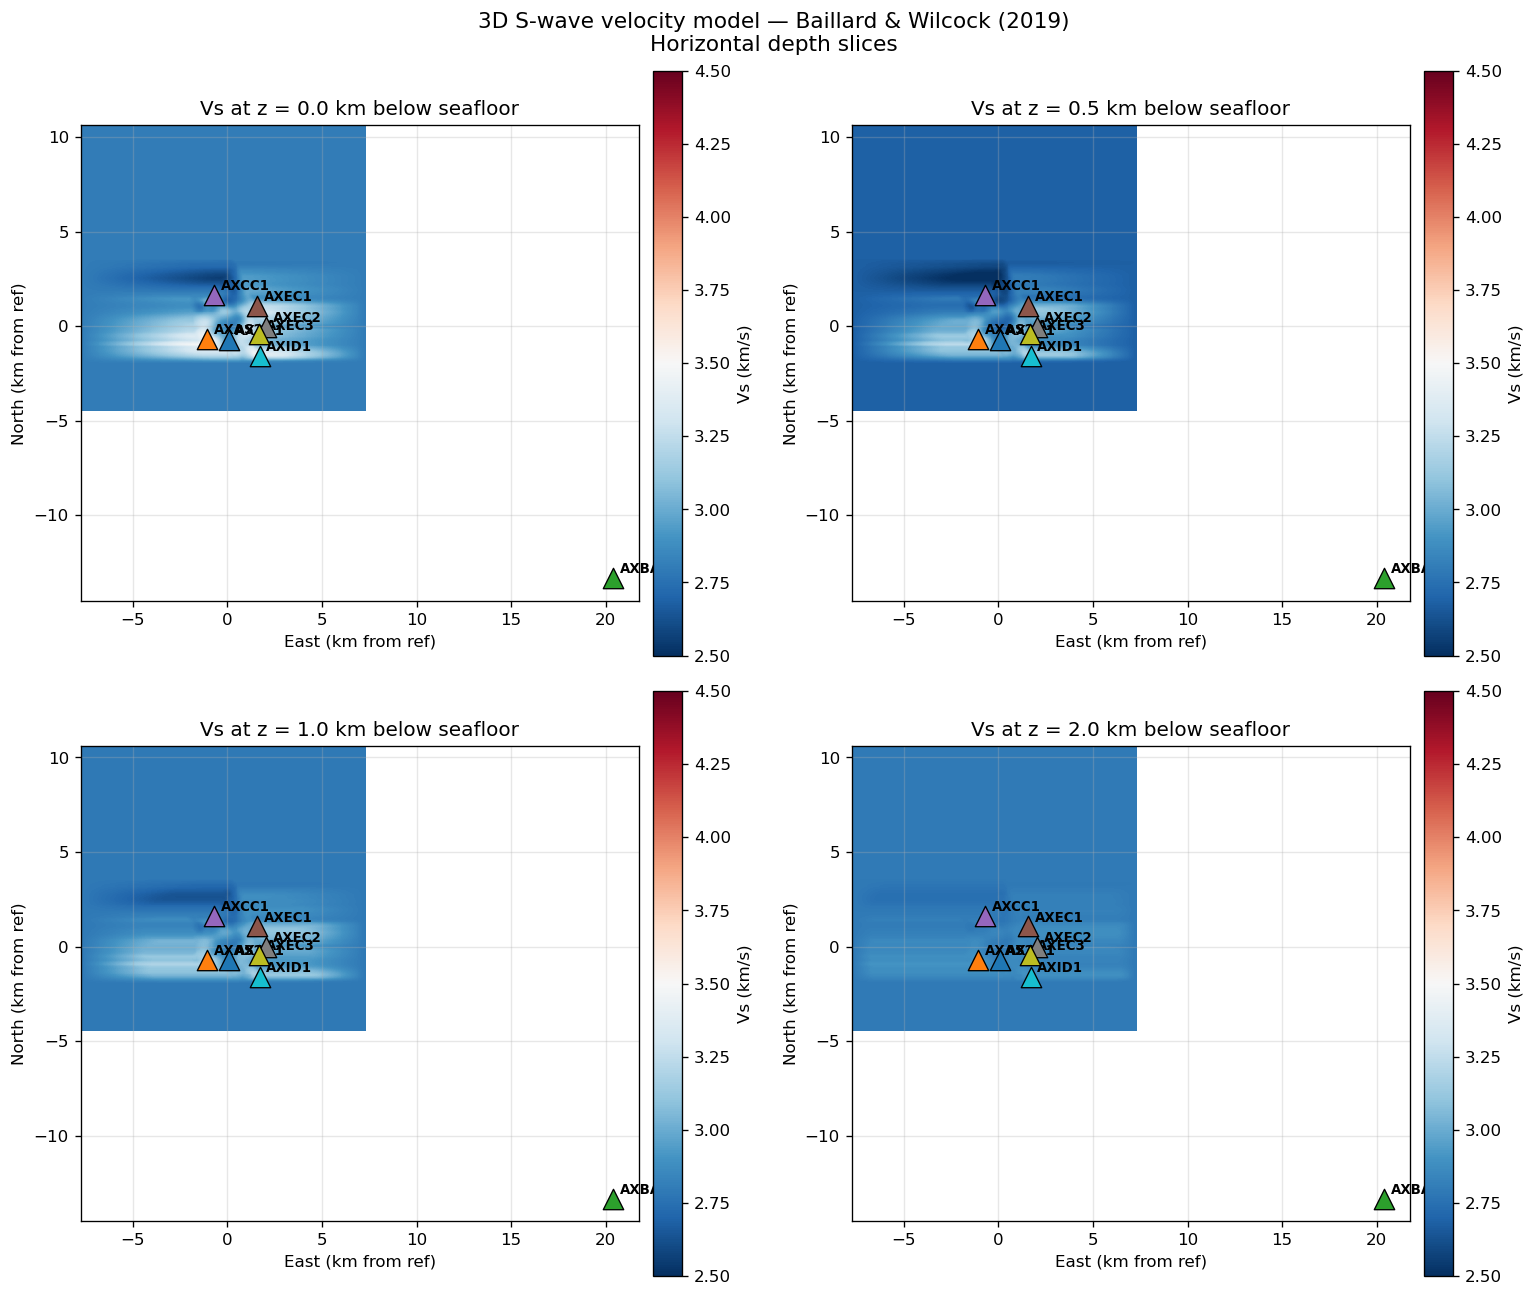

In [6]:
depth_levels = [0.0, 0.5, 1.0, 2.0]  # km below seafloor

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, z_sf in zip(axes.flatten(), depth_levels):
    iz = int(np.clip(round((z_sf + MEAN_SEAFLOOR_KM - NLL_OZ) / NLL_DZ), 0, NLL_NZ - 1))

    vslice = vel_3d[:, :, iz]   # shape (NX, NY); transpose for pcolormesh(x, y, Z[y,x])
    im = ax.pcolormesh(nll_x_nb, nll_y_nb, vslice.T,
                       cmap=vel_cmap, norm=vel_norm, shading='auto')
    plt.colorbar(im, ax=ax, label='Vs (km/s)', pad=0.02)

    for name, row in stations.iterrows():
        ax.scatter(row['x'], row['y'], marker='^', s=150,
                   color=sta_color.get(name, 'w'), edgecolors='k', linewidths=0.8, zorder=5)
        ax.annotate(name, (row['x'], row['y']), textcoords='offset points',
                    xytext=(4, 3), fontsize=8, fontweight='bold')

    ax.set_xlabel('East (km from ref)')
    ax.set_ylabel('North (km from ref)')
    ax.set_title(f'Vs at z = {z_sf:.1f} km below seafloor')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle('3D S-wave velocity model — Baillard & Wilcock (2019)\nHorizontal depth slices', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
stations

,lon,lat,elev_km,x,y,z
station,,,,,,
AXAS1,-129.999289,45.93356,-1.5290,0.055041,-0.716901,0.131388
AXAS2,-130.014100,45.93377,-1.5444,-1.091526,-0.693524,0.115988
AXBA1,-129.736700,45.82018,-2.6072,20.382891,-13.338362,0.000000
AXCC1,-130.008900,45.95468,-1.5280,-0.688977,1.634178,0.132388
AXEC1,-129.979700,45.94958,-1.5120,1.571488,1.066446,0.148388
AXEC2,-129.973800,45.93967,-1.5190,2.028225,-0.036736,0.141388
AXEC3,-129.978500,45.93607,-1.5160,1.664383,-0.437488,0.144388
AXID1,-129.978000,45.92573,-1.5275,1.703090,-1.588536,0.132888


In [ ]:
# Remove station rows AXBA1, AXID1 from catalog for ray coverage analysis
catalog = catalog[~catalog['station'].isin(['AXBA1', 'AXID1'])]
stations = stations[~stations.index.isin(['AXBA1', 'AXID1'])]

KeyError: 'station'

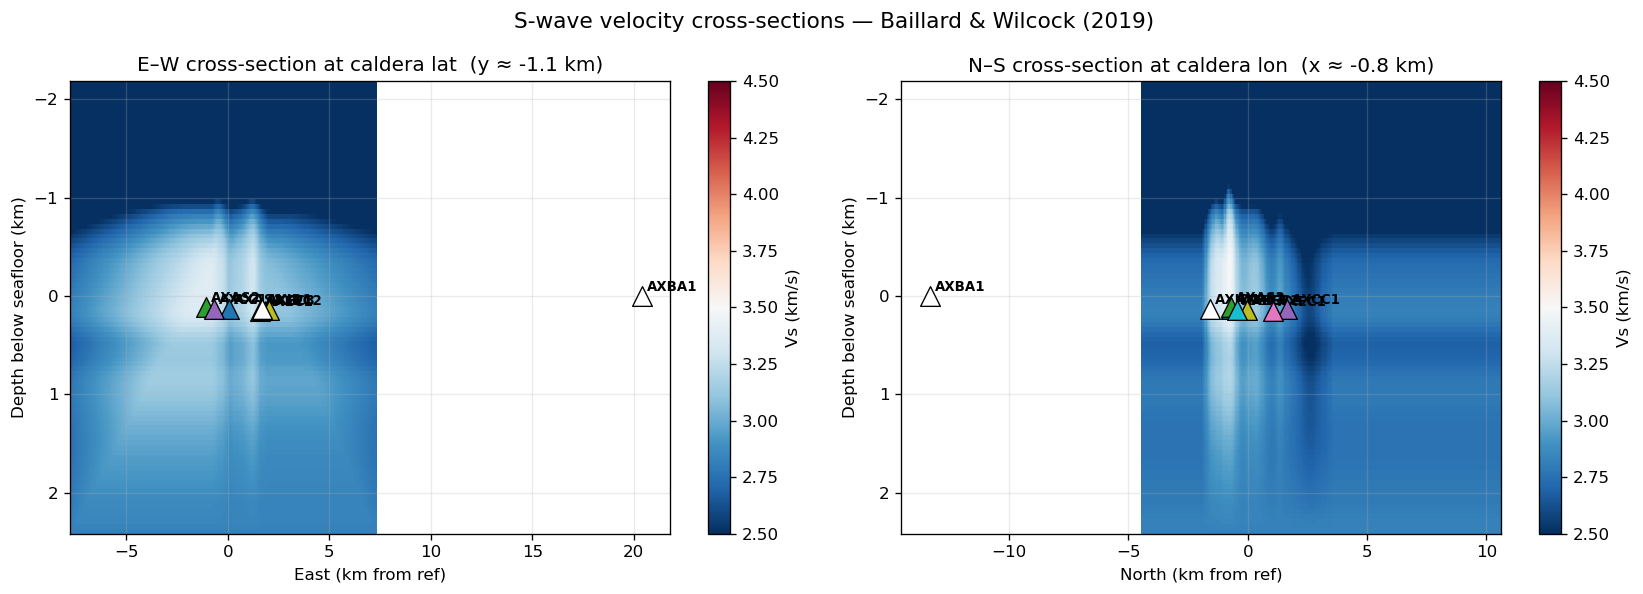

In [20]:
# Caldera center ≈ lat 45.93, lon -130.01 — used for cross-section slice positions
CAL_LAT, CAL_LON = 45.93, -130.01
cal_x_nb, cal_y_nb = ll_to_xy(CAL_LAT, CAL_LON)
iy_cal = int(np.clip(round((cal_y_nb + NB_TO_NLL_YOFF) / NLL_DY), 0, NLL_NY - 1))
ix_cal = int(np.clip(round((cal_x_nb + NB_TO_NLL_XOFF) / NLL_DX), 0, NLL_NX - 1))

vel_norm = mcolors.Normalize(vmin=2.5, vmax=4.5)
vel_cmap = cm.RdBu_r

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# E-W cross-section at caldera latitude
ew_slice = vel_3d[:, iy_cal, :]   # (NX, NZ)
ax = axes[0]
im = ax.pcolormesh(nll_x_nb, nll_z_sf, ew_slice.T,
                   cmap=vel_cmap, norm=vel_norm, shading='auto')
plt.colorbar(im, ax=ax, label='Vs (km/s)')
for name, row in stations.iterrows():
    ax.scatter(row['x'], row['z'], marker='^', s=140,
               color=sta_color.get(name, 'w'), edgecolors='k', linewidths=0.8, zorder=5)
    ax.annotate(name, (row['x'], row['z']), textcoords='offset points',
                xytext=(3, 3), fontsize=8, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('East (km from ref)')
ax.set_ylabel('Depth below seafloor (km)')
ax.set_title(f'E–W cross-section at caldera lat  (y ≈ {cal_y_nb:.1f} km)')
ax.grid(True, alpha=0.25)

# N-S cross-section at caldera longitude
ns_slice = vel_3d[ix_cal, :, :]   # (NY, NZ)
ax = axes[1]
im = ax.pcolormesh(nll_y_nb, nll_z_sf, ns_slice.T,
                   cmap=vel_cmap, norm=vel_norm, shading='auto')
plt.colorbar(im, ax=ax, label='Vs (km/s)')
for name, row in stations.iterrows():
    ax.scatter(row['y'], row['z'], marker='^', s=140,
               color=sta_color.get(name, 'w'), edgecolors='k', linewidths=0.8, zorder=5)
    ax.annotate(name, (row['y'], row['z']), textcoords='offset points',
                xytext=(3, 3), fontsize=8, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('North (km from ref)')
ax.set_ylabel('Depth below seafloor (km)')
ax.set_title(f'N–S cross-section at caldera lon  (x ≈ {cal_x_nb:.1f} km)')
ax.grid(True, alpha=0.25)

fig.suptitle('S-wave velocity cross-sections — Baillard & Wilcock (2019)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Subsampled Ray Tracing and Density Accumulation

A representative subsample of earthquake–station pairs is drawn proportionally from each station's catalog share. For each station the eikonal equation is solved once via PyKonal fast marching, then rays are traced only for the subsample. Each ray path accumulates counts into a 3D integer density grid on the same 302×302×92 NLL voxel space. This gives spatial coverage without tracing all 585k paths.

In [8]:
# --- Subsample catalog proportionally by station ---
N_SAMPLE = 8000
rng = np.random.default_rng(42)

sample_frames = []
for sta in sorted(catalog['station'].unique()):
    sub = catalog[catalog['station'] == sta]
    n_sta = max(1, round(N_SAMPLE * len(sub) / len(catalog)))
    sample_frames.append(sub.sample(n=min(n_sta, len(sub)), random_state=42))

sample = pd.concat(sample_frames).reset_index(drop=True)
print(f'Subsampled {len(sample):,} / {len(catalog):,} ray pairs')
print(sample.groupby('station').size().rename('n_sampled'))

# Station coordinates and geometry for the subsample
sample['st_x'] = sample['station'].map(stations['x'])
sample['st_y'] = sample['station'].map(stations['y'])
sample['st_z'] = sample['station'].map(stations['z'])
dx = sample['st_x'] - sample['eq_x']
dy = sample['st_y'] - sample['eq_y']
dz = sample['st_z'] - sample['eq_z']
sample['horiz_km'] = np.hypot(dx, dy).values
sample['ray_km']   = np.sqrt(dx**2 + dy**2 + dz**2).values

# 3D density accumulators — same grid as velocity model
density = np.zeros((NLL_NX, NLL_NY, NLL_NZ), dtype=np.int32)
station_density = {sta: np.zeros((NLL_NX, NLL_NY, NLL_NZ), dtype=np.int32)
                   for sta in sorted(sample['station'].unique())}

n = len(sample)
travel_time_arr = np.full(n, np.nan)
incidence_arr   = np.full(n, np.nan)
back_az_arr     = np.full(n, np.nan)

vel_3d_f64 = vel_3d.astype(np.float64)

for sta in sorted(sample['station'].unique()):
    mask    = sample['station'] == sta
    indices = np.where(mask.values)[0]

    sta_row = stations.loc[sta]
    sx = float(sta_row['x']) + NB_TO_NLL_XOFF
    sy = float(sta_row['y']) + NB_TO_NLL_YOFF
    sz = float(sta_row['z']) + MEAN_SEAFLOOR_KM
    src_ix = int(np.clip(round(sx / NLL_DX), 0, NLL_NX - 1))
    src_iy = int(np.clip(round(sy / NLL_DY), 0, NLL_NY - 1))
    src_iz = int(np.clip(round((sz - NLL_OZ) / NLL_DZ), 0, NLL_NZ - 1))

    t0 = time.time()
    solver = pykonal.EikonalSolver(coord_sys='cartesian')
    solver.vv.min_coords     = (NLL_OX, NLL_OY, NLL_OZ)
    solver.vv.node_intervals = (NLL_DX, NLL_DY, NLL_DZ)
    solver.vv.npts           = (NLL_NX, NLL_NY, NLL_NZ)
    solver.vv.values         = vel_3d_f64
    solver.tt.values[src_ix, src_iy, src_iz] = 0.0
    solver.unknown[src_ix, src_iy, src_iz]   = False
    solver.trial.push(src_ix, src_iy, src_iz)
    solver.solve()
    tt_field = solver.tt

    eq_x_nll = sample.loc[mask, 'eq_x'].values + NB_TO_NLL_XOFF
    eq_y_nll = sample.loc[mask, 'eq_y'].values + NB_TO_NLL_YOFF
    eq_z_nll = sample.loc[mask, 'eq_z'].values + MEAN_SEAFLOOR_KM

    n_ok = 0
    for i, pos in enumerate(indices):
        eq_nll = np.array([eq_x_nll[i], eq_y_nll[i], eq_z_nll[i]], dtype=np.float64)
        ray = tt_field.trace_ray(eq_nll)
        if ray is None or len(ray) < 2:
            continue

        travel_time_arr[pos] = tt_field.value(eq_nll)

        seg = ray[-1] - ray[-2]
        h = np.hypot(seg[0], seg[1])
        incidence_arr[pos] = np.degrees(np.arctan2(h, abs(seg[2])))
        back_az_arr[pos]   = np.degrees(np.arctan2(-seg[0], -seg[1])) % 360

        # Accumulate voxel counts along the ray path
        ix = np.clip(np.round(ray[:, 0] / NLL_DX).astype(int), 0, NLL_NX - 1)
        iy = np.clip(np.round(ray[:, 1] / NLL_DY).astype(int), 0, NLL_NY - 1)
        iz = np.clip(np.round((ray[:, 2] - NLL_OZ) / NLL_DZ).astype(int), 0, NLL_NZ - 1)
        np.add.at(density, (ix, iy, iz), 1)
        np.add.at(station_density[sta], (ix, iy, iz), 1)

        n_ok += 1

    print(f'{sta}: {n_ok}/{len(indices)} rays  ({time.time()-t0:.1f}s)')

sample['travel_time'] = travel_time_arr
sample['incidence']   = incidence_arr
sample['back_az']     = back_az_arr
sample = sample.dropna(subset=['incidence']).reset_index(drop=True)

print(f'\nTotal: {len(sample):,} rays traced successfully')
print(f'Incidence: {sample["incidence"].min():.1f}°–{sample["incidence"].max():.1f}°  '
      f'(median {sample["incidence"].median():.1f}°)')
print(f'Density grid max: {density.max()} counts/voxel')

Subsampled 8,000 / 585,274 ray pairs
station
AXAS1    1063
AXAS2     706
AXCC1    1015
AXEC1    1717
AXEC2    1697
AXEC3    1802
Name: n_sampled, dtype: int64
AXAS1: 1049/1063 rays  (231.7s)
AXAS2: 693/706 rays  (150.9s)
AXCC1: 1002/1015 rays  (226.3s)
AXEC1: 1692/1717 rays  (385.3s)
AXEC2: 1683/1697 rays  (357.9s)
AXEC3: 1779/1802 rays  (382.0s)

Total: 7,898 rays traced successfully
Incidence: 0.6°–90.0°  (median 66.7°)
Density grid max: 5086 counts/voxel


## 5. Plan View — Epicenters and Station Locations

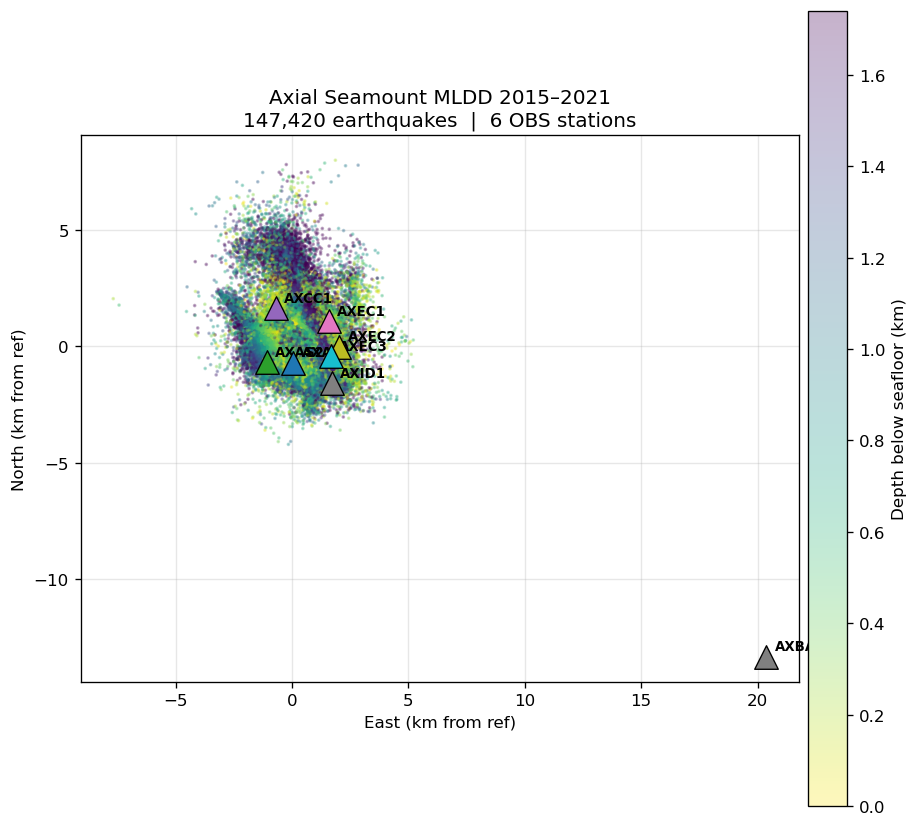

In [9]:
sta_cmap = plt.cm.tab10
sta_list = sorted(catalog['station'].unique())
sta_color = {s: sta_cmap(i / max(len(sta_list) - 1, 1)) for i, s in enumerate(sta_list)}

unique_eqs = catalog.drop_duplicates(subset=['event_datetime', 'event_lat', 'event_lon', 'event_depth'])

fig, ax = plt.subplots(figsize=(8, 7))

sc = ax.scatter(
    unique_eqs['eq_x'], unique_eqs['eq_y'],
    c=unique_eqs['eq_z'], cmap='viridis_r', vmin=0, vmax=unique_eqs['eq_z'].quantile(0.95),
    s=1.5, alpha=0.3, zorder=2, label='earthquakes'
)
plt.colorbar(sc, ax=ax, label='Depth below seafloor (km)', pad=0.01)

for name, row in stations.iterrows():
    ax.scatter(row['x'], row['y'], marker='^', s=200,
               color=sta_color.get(name, 'gray'), edgecolors='k', linewidths=0.8, zorder=5)
    ax.annotate(name, (row['x'], row['y']), textcoords='offset points',
                xytext=(5, 4), fontsize=8, fontweight='bold')

ax.set_xlabel('East (km from ref)')
ax.set_ylabel('North (km from ref)')
ax.set_title(f'Axial Seamount MLDD 2015–2021\n{len(unique_eqs):,} earthquakes  |  {len(sta_list)} OBS stations')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Ray Density Cross-Sections

E–W (x–z) and N–S (y–z) density projections: voxel counts are summed along the perpendicular axis and overlaid on the velocity model background. Color scale is logarithmic; voxels with zero counts are masked transparent.

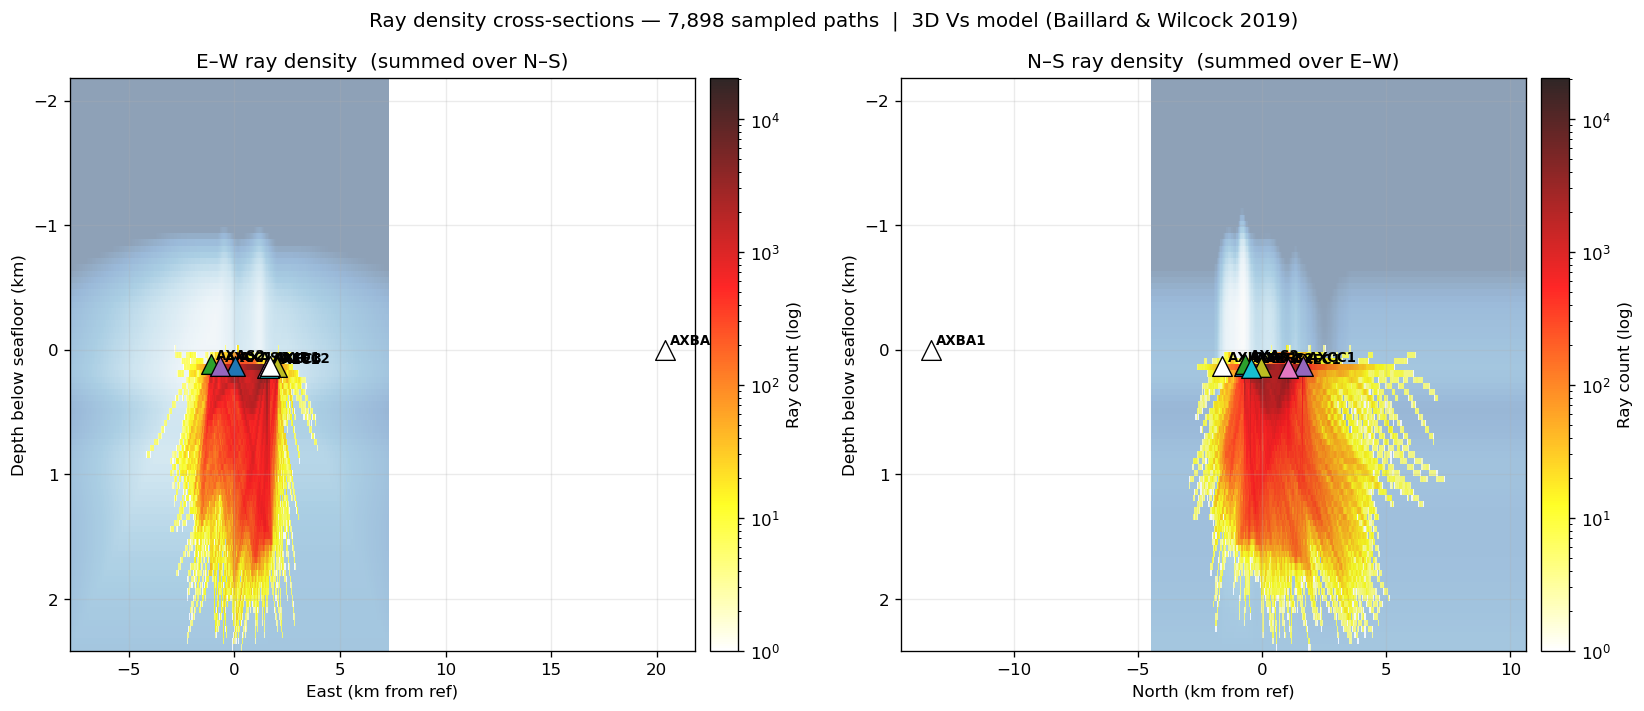

In [10]:
from matplotlib.colors import LogNorm

# Project density along each axis
dens_ew   = density.sum(axis=1)   # (NX, NZ): E-W × depth
dens_ns   = density.sum(axis=0)   # (NY, NZ): N-S × depth
dens_plan = density.sum(axis=2)   # (NX, NY): plan view

dens_cmap = 'hot_r'
dens_max  = max(dens_ew.max(), dens_ns.max(), 2)
dens_norm = LogNorm(vmin=1, vmax=dens_max)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# E-W cross-section (summed over N-S)
ax = axes[0]
ax.pcolormesh(nll_x_nb, nll_z_sf, vel_3d[:, iy_cal, :].T,
              cmap=vel_cmap, norm=vel_norm, alpha=0.45, shading='auto')
ew_ma = np.ma.masked_where(dens_ew == 0, dens_ew.astype(float))
im = ax.pcolormesh(nll_x_nb, nll_z_sf, ew_ma.T, cmap=dens_cmap,
                   norm=dens_norm, alpha=0.85, shading='auto')
plt.colorbar(im, ax=ax, label='Ray count (log)', pad=0.02)
for name, row in stations.iterrows():
    ax.scatter(row['x'], row['z'], marker='^', s=140,
               color=sta_color.get(name, 'w'), edgecolors='k', linewidths=0.8, zorder=5)
    ax.annotate(name, (row['x'], row['z']), textcoords='offset points',
                xytext=(3, 3), fontsize=8, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('East (km from ref)')
ax.set_ylabel('Depth below seafloor (km)')
ax.set_title('E–W ray density  (summed over N–S)')
ax.grid(True, alpha=0.25)

# N-S cross-section (summed over E-W)
ax = axes[1]
ax.pcolormesh(nll_y_nb, nll_z_sf, vel_3d[ix_cal, :, :].T,
              cmap=vel_cmap, norm=vel_norm, alpha=0.45, shading='auto')
ns_ma = np.ma.masked_where(dens_ns == 0, dens_ns.astype(float))
im = ax.pcolormesh(nll_y_nb, nll_z_sf, ns_ma.T, cmap=dens_cmap,
                   norm=dens_norm, alpha=0.85, shading='auto')
plt.colorbar(im, ax=ax, label='Ray count (log)', pad=0.02)
for name, row in stations.iterrows():
    ax.scatter(row['y'], row['z'], marker='^', s=140,
               color=sta_color.get(name, 'w'), edgecolors='k', linewidths=0.8, zorder=5)
    ax.annotate(name, (row['y'], row['z']), textcoords='offset points',
                xytext=(3, 3), fontsize=8, fontweight='bold')
ax.invert_yaxis()
ax.set_xlabel('North (km from ref)')
ax.set_ylabel('Depth below seafloor (km)')
ax.set_title('N–S ray density  (summed over E–W)')
ax.grid(True, alpha=0.25)

fig.suptitle(f'Ray density cross-sections — {len(sample):,} sampled paths  |  '
             f'3D Vs model (Baillard & Wilcock 2019)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Per-Station Ray Density Panels

E–W density cross-section for each station individually, using counts accumulated only from that station's rays.

/var/folders/rj/g1dwlppj5f33mzwsfvn7tr9m0000gn/T/ipykernel_2426/834609021.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


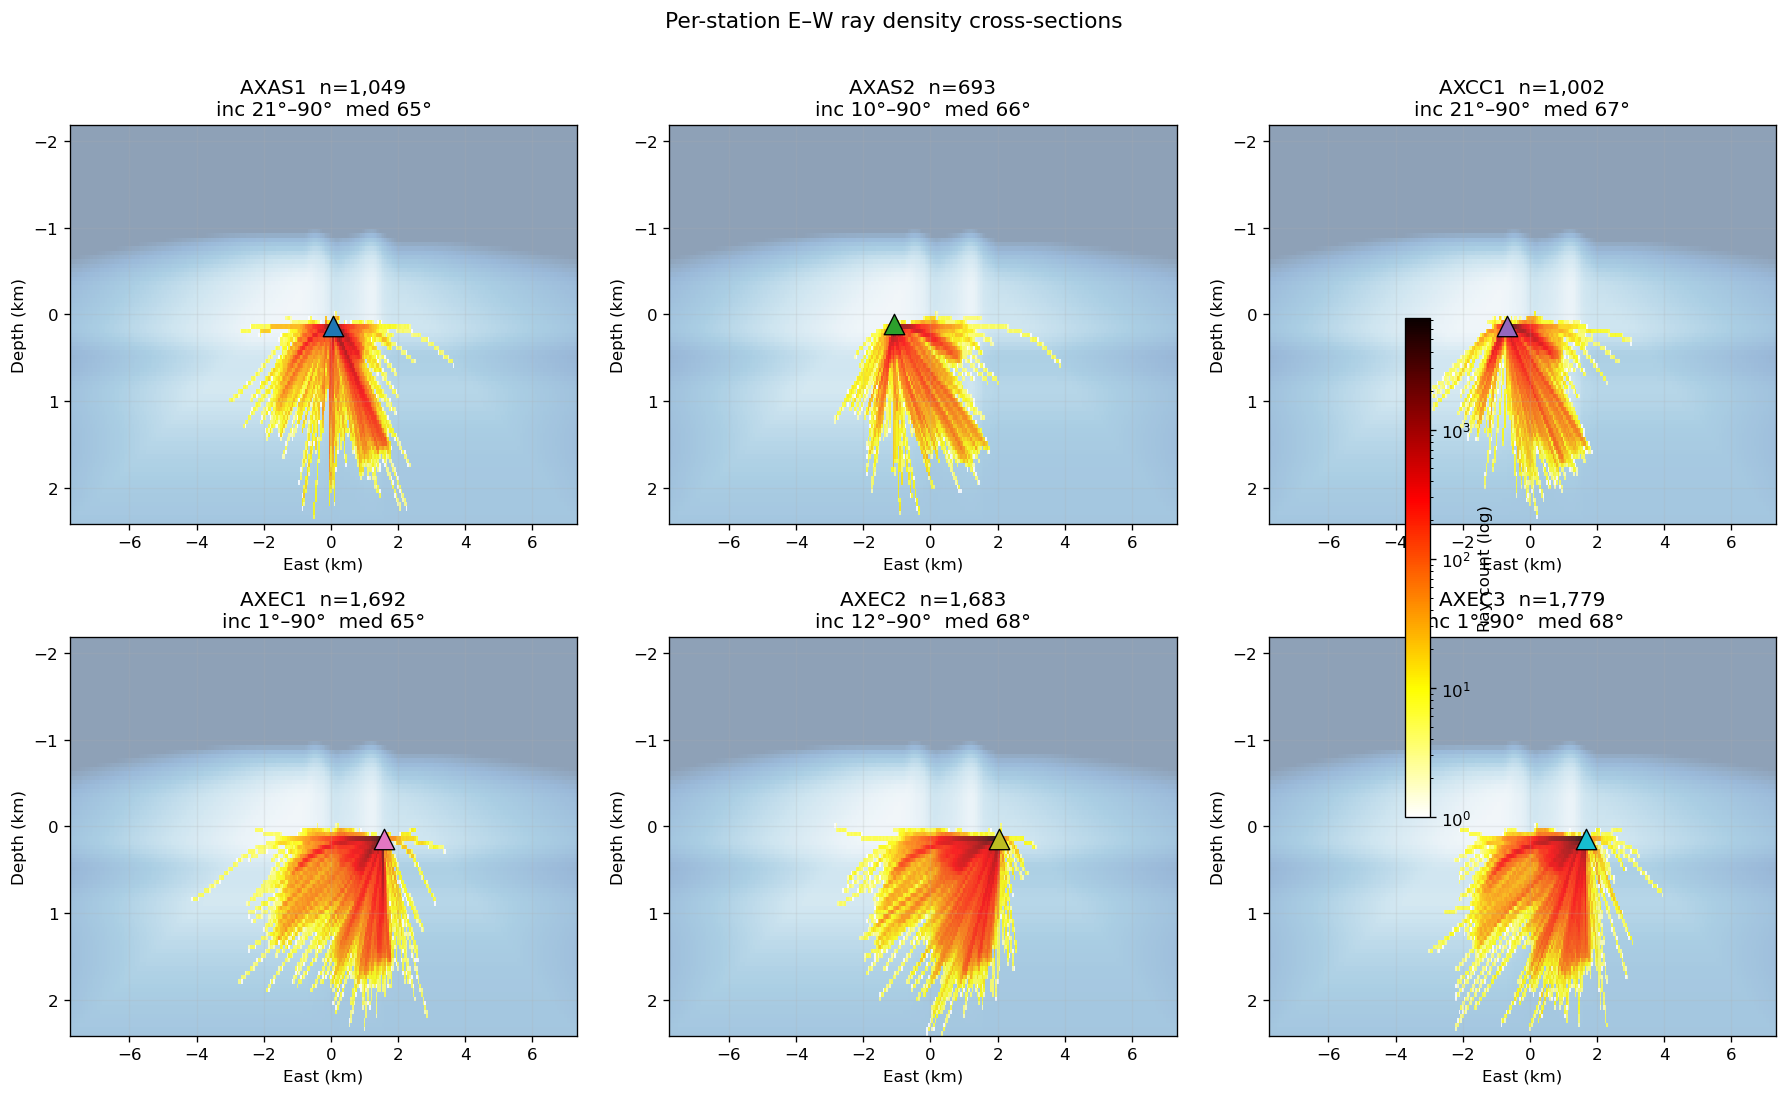

In [11]:
ncols = 3
nrows = int(np.ceil(len(sta_list) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
axes = axes.flatten()

sta_dens_max = max(station_density[s].sum(axis=1).max() for s in sta_list if s in station_density)
sta_dens_norm = LogNorm(vmin=1, vmax=max(sta_dens_max, 2))

for i, sta in enumerate(sta_list):
    ax = axes[i]
    sub = sample[sample['station'] == sta]

    sd = station_density[sta].sum(axis=1)   # (NX, NZ) — E-W × depth
    sd_ma = np.ma.masked_where(sd == 0, sd.astype(float))

    ax.pcolormesh(nll_x_nb, nll_z_sf, vel_3d[:, iy_cal, :].T,
                  cmap=vel_cmap, norm=vel_norm, alpha=0.45, shading='auto')
    im = ax.pcolormesh(nll_x_nb, nll_z_sf, sd_ma.T,
                       cmap=dens_cmap, norm=sta_dens_norm, alpha=0.85, shading='auto')

    if sta in stations.index:
        r = stations.loc[sta]
        ax.scatter(r['x'], r['z'], marker='^', s=150,
                   color=sta_color[sta], edgecolors='k', linewidths=0.8, zorder=5)

    ax.invert_yaxis()
    ax.set_xlabel('East (km)')
    ax.set_ylabel('Depth (km)')
    inc_vals = sub['incidence']
    ax.set_title(f'{sta}  n={len(sub):,}\n'
                 f'inc {inc_vals.min():.0f}°–{inc_vals.max():.0f}°  '
                 f'med {inc_vals.median():.0f}°')
    ax.grid(True, alpha=0.2)

for ax in axes[len(sta_list):]:
    ax.set_visible(False)

fig.colorbar(cm.ScalarMappable(cmap=dens_cmap, norm=sta_dens_norm),
             ax=axes[:len(sta_list)], label='Ray count (log)', shrink=0.6)
fig.suptitle('Per-station E–W ray density cross-sections', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Plan-View Ray Density at Depth Slices

Horizontal slices through the 3D density grid at several depths below the seafloor, overlaid on the velocity model. Reveals which parts of the caldera volume are sampled at each depth level.

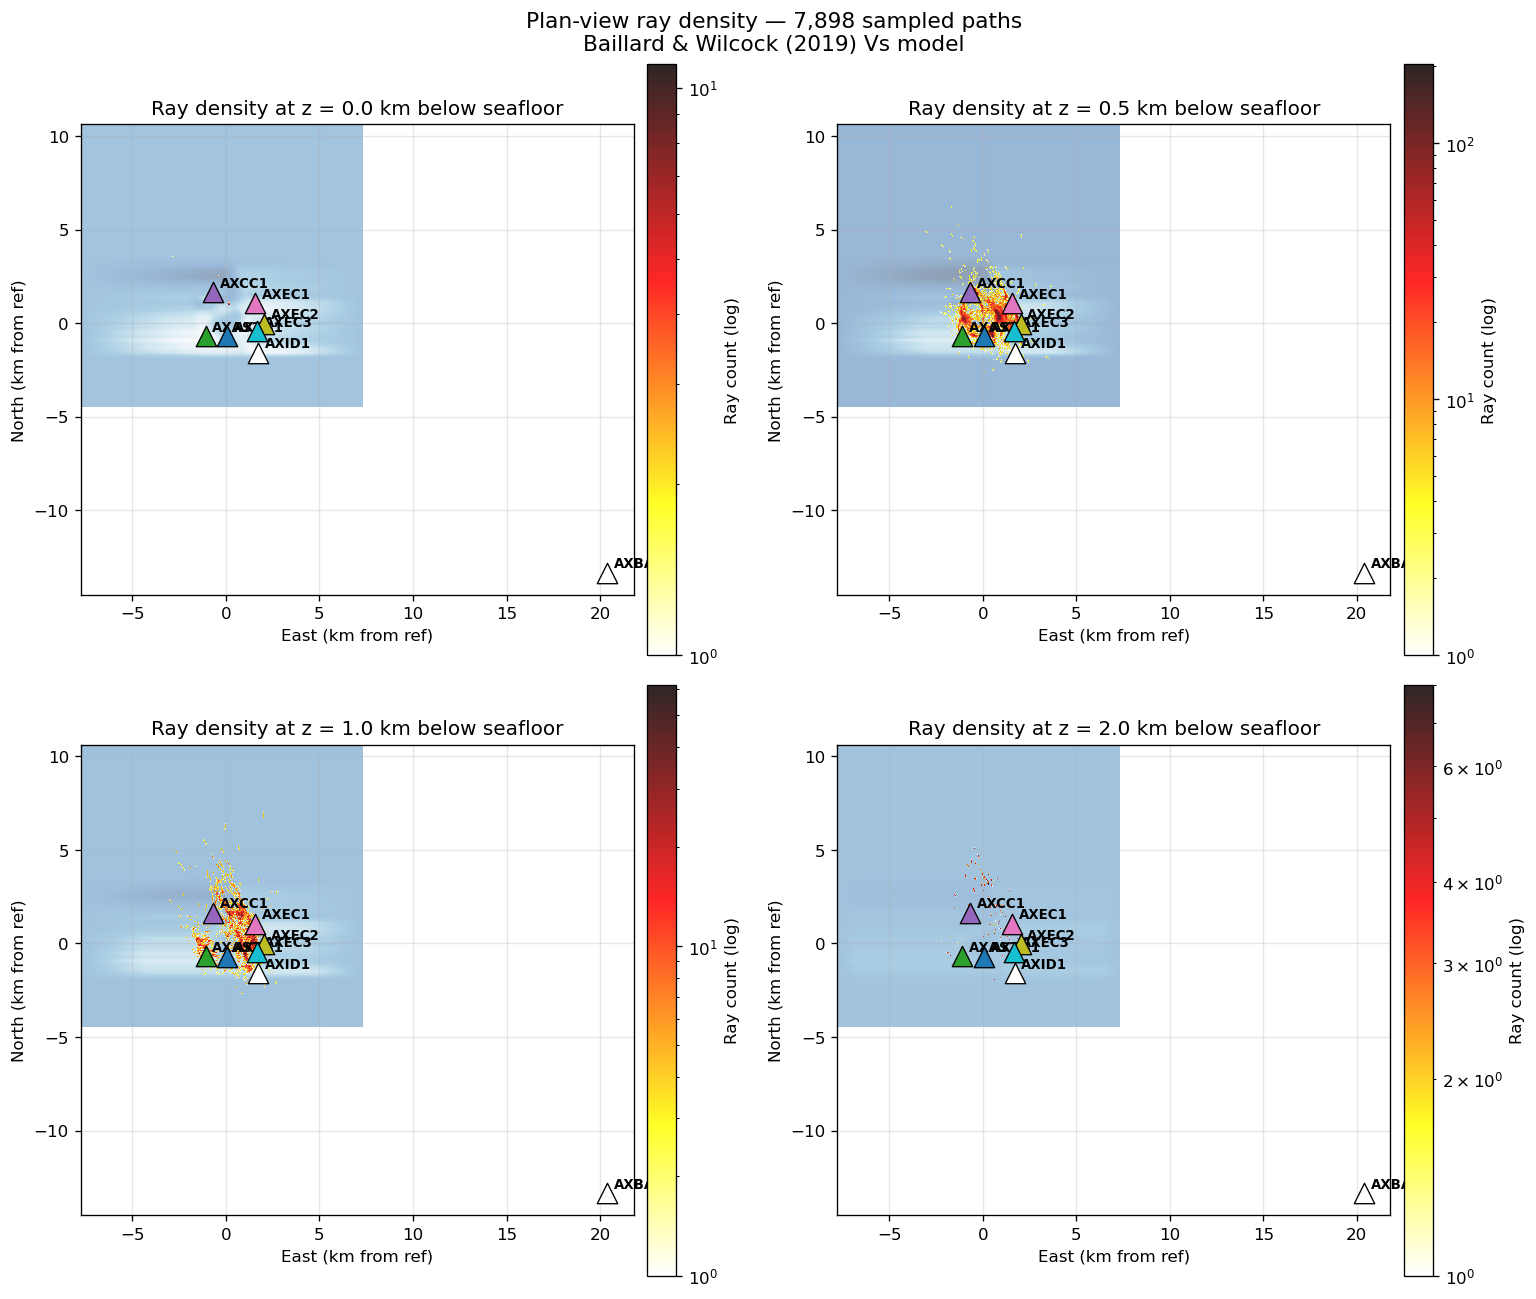

In [12]:
depth_levels = [0.0, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, z_sf in zip(axes.flatten(), depth_levels):
    iz = int(np.clip(round((z_sf + MEAN_SEAFLOOR_KM - NLL_OZ) / NLL_DZ), 0, NLL_NZ - 1))

    ax.pcolormesh(nll_x_nb, nll_y_nb, vel_3d[:, :, iz].T,
                  cmap=vel_cmap, norm=vel_norm, alpha=0.45, shading='auto')

    dens_slice = density[:, :, iz].astype(float)
    dens_ma = np.ma.masked_where(dens_slice == 0, dens_slice)
    slice_norm = LogNorm(vmin=1, vmax=max(dens_slice.max(), 2))
    im = ax.pcolormesh(nll_x_nb, nll_y_nb, dens_ma.T,
                       cmap=dens_cmap, norm=slice_norm, alpha=0.85, shading='auto')
    plt.colorbar(im, ax=ax, label='Ray count (log)', pad=0.02)

    for name, row in stations.iterrows():
        ax.scatter(row['x'], row['y'], marker='^', s=150,
                   color=sta_color.get(name, 'w'), edgecolors='k', linewidths=0.8, zorder=5)
        ax.annotate(name, (row['x'], row['y']), textcoords='offset points',
                    xytext=(4, 3), fontsize=8, fontweight='bold')

    ax.set_xlabel('East (km from ref)')
    ax.set_ylabel('North (km from ref)')
    ax.set_title(f'Ray density at z = {z_sf:.1f} km below seafloor')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Plan-view ray density — {len(sample):,} sampled paths\n'
             f'Baillard & Wilcock (2019) Vs model', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Incidence Angle Statistics

Computed from the representative subsample; distributions are representative of the full catalog since sampling was proportional by station.

/var/folders/rj/g1dwlppj5f33mzwsfvn7tr9m0000gn/T/ipykernel_2426/2597017724.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


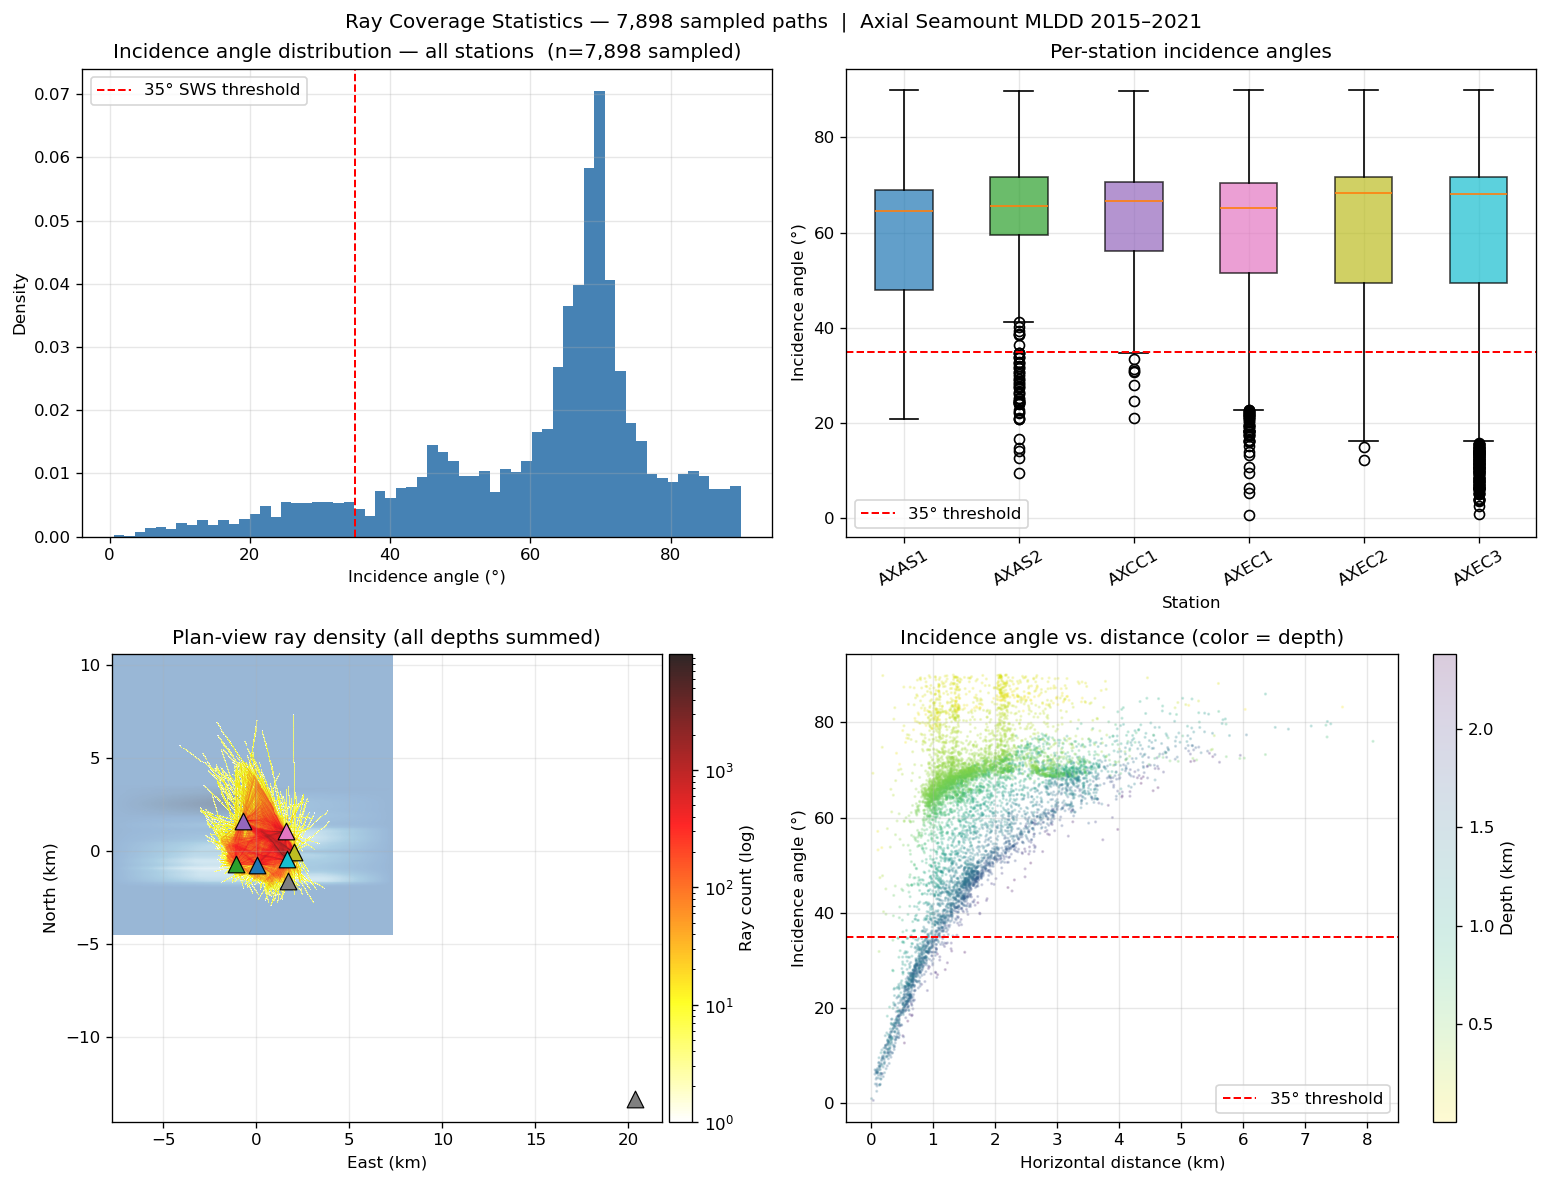

Rays with incidence < 35°: 831 / 7,898  (10.5%)
Median incidence angle: 66.7°


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (a) Overall incidence angle histogram
ax = axes[0, 0]
ax.hist(sample['incidence'], bins=60, color='steelblue', edgecolor='none', density=True)
ax.axvline(35, color='r', ls='--', lw=1.2, label='35° SWS threshold')
ax.set_xlabel('Incidence angle (°)')
ax.set_ylabel('Density')
ax.set_title(f'Incidence angle distribution — all stations  (n={len(sample):,} sampled)')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Per-station box plots
ax = axes[0, 1]
bp = ax.boxplot(
    [sample[sample['station'] == s]['incidence'].values for s in sta_list],
    labels=sta_list, patch_artist=True, widths=0.5
)
for patch, sta in zip(bp['boxes'], sta_list):
    patch.set_facecolor(sta_color.get(sta, 'gray'))
    patch.set_alpha(0.7)
ax.axhline(35, color='r', ls='--', lw=1.2, label='35° threshold')
ax.set_xlabel('Station')
ax.set_ylabel('Incidence angle (°)')
ax.set_title('Per-station incidence angles')
ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(True, alpha=0.3)

# (c) Plan-view integrated ray density (all depths summed)
ax = axes[1, 0]
iz_sf0 = int(np.clip(round((0.5 + MEAN_SEAFLOOR_KM - NLL_OZ) / NLL_DZ), 0, NLL_NZ - 1))
ax.pcolormesh(nll_x_nb, nll_y_nb, vel_3d[:, :, iz_sf0].T,
              cmap=vel_cmap, norm=vel_norm, alpha=0.45, shading='auto')
dp_norm = LogNorm(vmin=1, vmax=max(dens_plan.max(), 2))
dp_ma = np.ma.masked_where(dens_plan == 0, dens_plan.astype(float))
im = ax.pcolormesh(nll_x_nb, nll_y_nb, dp_ma.T, cmap=dens_cmap,
                   norm=dp_norm, alpha=0.85, shading='auto')
plt.colorbar(im, ax=ax, label='Ray count (log)', pad=0.01)
for name, row in stations.iterrows():
    ax.scatter(row['x'], row['y'], marker='^', s=100,
               color=sta_color.get(name, 'gray'), edgecolors='k', linewidths=0.7, zorder=5)
ax.set_xlabel('East (km)')
ax.set_ylabel('North (km)')
ax.set_aspect('equal')
ax.set_title('Plan-view ray density (all depths summed)')
ax.grid(True, alpha=0.25)

# (d) Incidence angle vs. horizontal distance
ax = axes[1, 1]
sc = ax.scatter(sample['horiz_km'], sample['incidence'],
                c=sample['eq_z'], cmap='viridis_r', s=0.8, alpha=0.2)
plt.colorbar(sc, ax=ax, label='Depth (km)')
ax.axhline(35, color='r', ls='--', lw=1.2, label='35° threshold')
ax.set_xlabel('Horizontal distance (km)')
ax.set_ylabel('Incidence angle (°)')
ax.set_title('Incidence angle vs. distance (color = depth)')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle(f'Ray Coverage Statistics — {len(sample):,} sampled paths  |  Axial Seamount MLDD 2015–2021',
             fontsize=12)
plt.tight_layout()
plt.show()

n_below35 = (sample['incidence'] < 35).sum()
print(f'Rays with incidence < 35°: {n_below35:,} / {len(sample):,}  ({100*n_below35/len(sample):.1f}%)')
print(f'Median incidence angle: {sample["incidence"].median():.1f}°')

In [41]:
# Plan-view ray density — clean high-resolution export (no labels, no velocity background)
fig, ax = plt.subplots(1, 1, figsize=(20*5, 20*5), facecolor='white')

dp_norm = LogNorm(vmin=1, vmax=max(dens_plan.max(), 2))
dp_ma   = np.ma.masked_where(dens_plan == 0, dens_plan.astype(float))
ax.pcolormesh(nll_x_nb, nll_y_nb, dp_ma.T, cmap=dens_cmap,
              norm=dp_norm, alpha=0.85, shading='auto')

for name, row in stations.iterrows():
    ax.scatter(row['x'], row['y'], marker='^', s=300,
               color=sta_color.get(name, 'gray'), edgecolors='k', linewidths=1.0, zorder=5)

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout(pad=0)
plt.savefig('../results/ray_density_planview_clean.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

## 10. Azimuthal Coverage — Rose Diagrams

NameError: name 'inc_cmap' is not defined

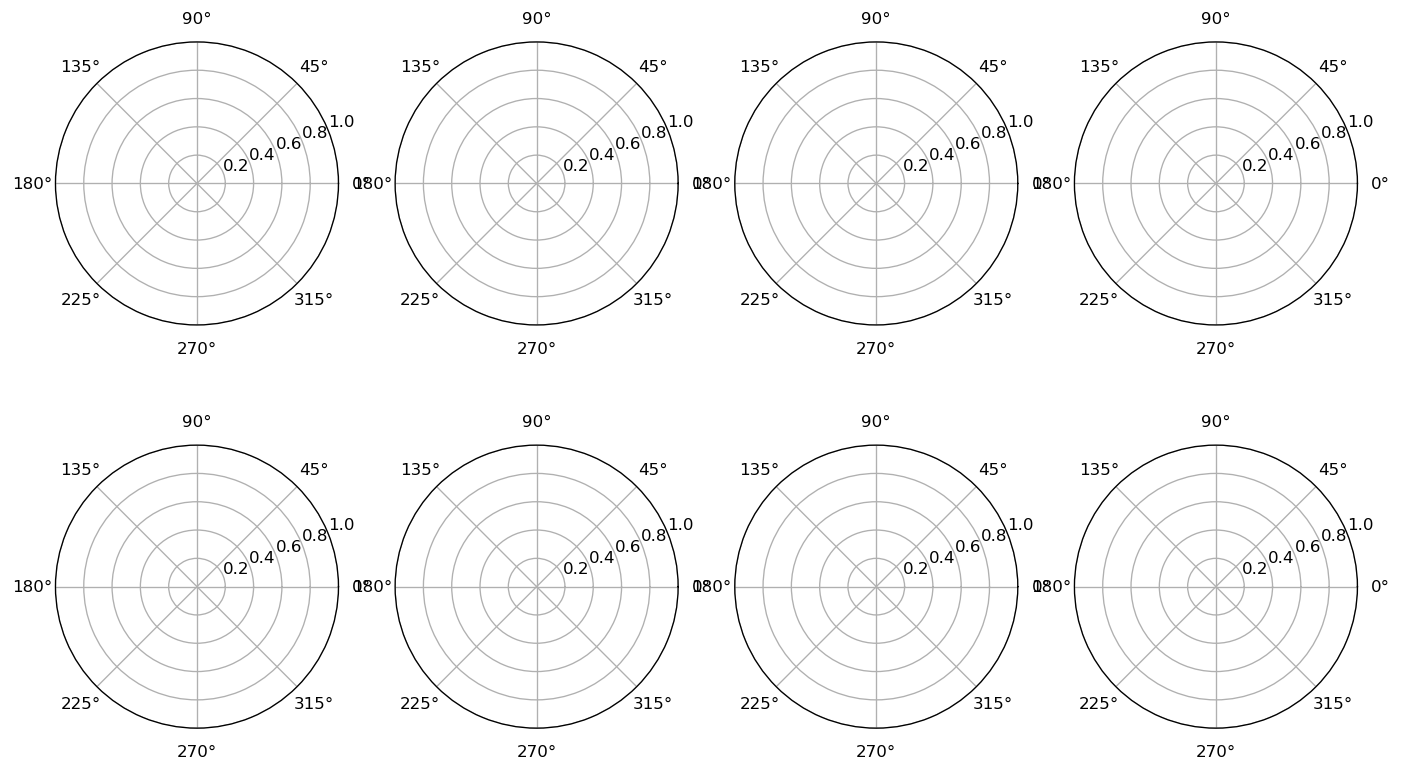

In [15]:
ncols = 4
nrows = int(np.ceil(len(sta_list) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows),
                          subplot_kw=dict(projection='polar'))
axes = axes.flatten()
bins_az = np.linspace(0, 2 * np.pi, 37)

for i, sta in enumerate(sta_list):
    ax  = axes[i]
    sub = sample[sample['station'] == sta]
    az  = np.radians(sub['back_az'].values)

    counts, _ = np.histogram(az, bins=bins_az)
    centers   = (bins_az[:-1] + bins_az[1:]) / 2
    width     = bins_az[1] - bins_az[0]

    mean_inc = np.array([
        sub['incidence'].values[(az >= b0) & (az < b1)].mean()
        if ((az >= b0) & (az < b1)).any() else 0
        for b0, b1 in zip(bins_az[:-1], bins_az[1:])
    ])

    ax.bar(centers, counts, width=width, color=inc_cmap(inc_norm(mean_inc)), alpha=0.85)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title(f'{sta}  n={len(sub):,}', pad=10, fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[len(sta_list):]:
    ax.set_visible(False)

sm = cm.ScalarMappable(cmap=inc_cmap, norm=inc_norm)
sm.set_array([])
fig.colorbar(sm, ax=axes[:len(sta_list)], label='Mean incidence angle (°)', shrink=0.5, pad=0.08)
fig.suptitle('Azimuthal coverage per station  (bar color = mean incidence angle)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()